### Importation librairies

In [1]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import os
from torchvision import transforms
from torchvision.transforms import v2 
from tqdm import tqdm
from PIL import Image, ImageOps

### Exploration & Visualisation 

In [2]:
root_dir = "IDC_regular_ps50_idx5"  

healthy_images = []
cancer_images = []

for patient_folder in os.listdir(root_dir):
    patient_path = os.path.join(root_dir, patient_folder)
    if os.path.isdir(patient_path):
        healthy_path = os.path.join(patient_path, "0")
        if os.path.isdir(healthy_path):
            healthy_images += [os.path.join(healthy_path, img) for img in os.listdir(healthy_path)]
        cancer_path = os.path.join(patient_path, "1")
        if os.path.isdir(cancer_path):
            cancer_images += [os.path.join(cancer_path, img) for img in os.listdir(cancer_path)]

print(f"Nombre d'images saines : {len(healthy_images)}")
print(f"Nombre d'images cancéreuses : {len(cancer_images)}")

Nombre d'images saines : 129025
Nombre d'images cancéreuses : 57253


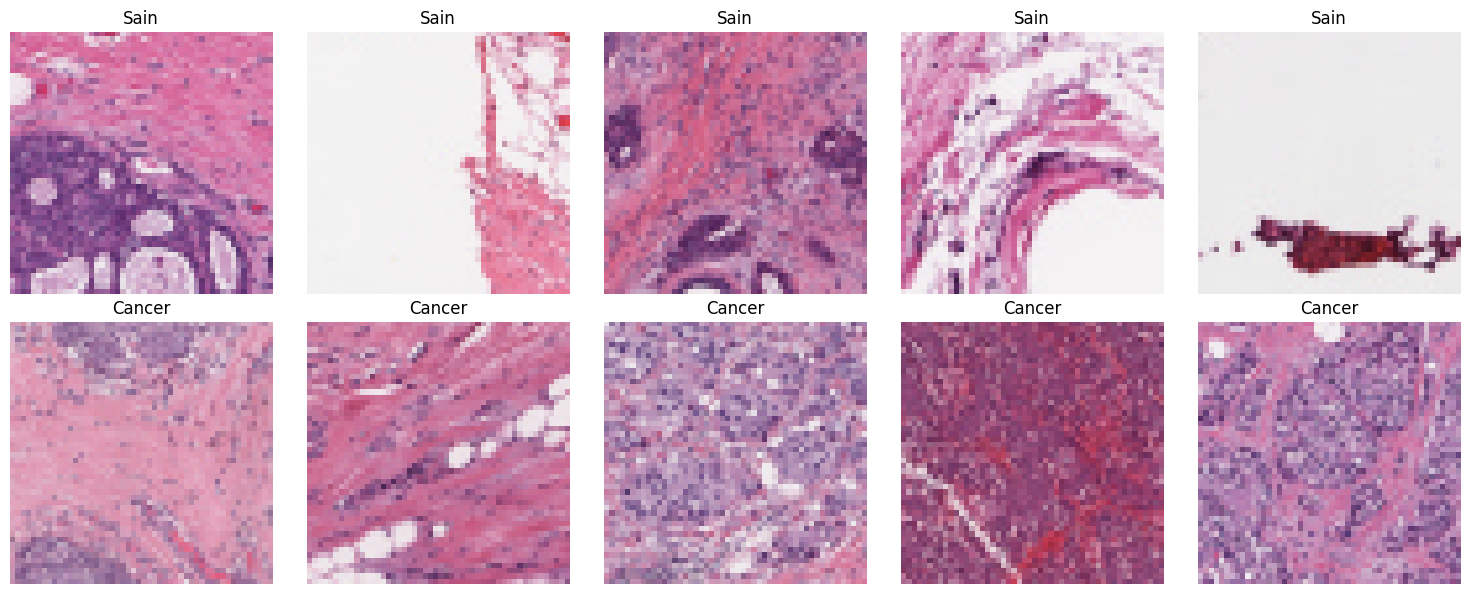

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    img_healthy = Image.open(random.choice(healthy_images))
    axes[0, i].imshow(img_healthy)
    axes[0, i].set_title("Sain")
    axes[0, i].axis("off")
    img_cancer = Image.open(random.choice(cancer_images))
    axes[1, i].imshow(img_cancer)
    axes[1, i].set_title("Cancer")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

In [9]:
from PIL import Image

# Taille de 10 images saines au hasard
healthy_shapes = [Image.open(path).size for path in random.sample(healthy_images, 10)]
# Taille de 10 images cancéreuses au hasard
cancer_shapes = [Image.open(path).size for path in random.sample(cancer_images, 10)]

print("Taille d'images saines (exemple) :", healthy_shapes)
print("Taille d'images cancéreuses (exemple) :", cancer_shapes)


Taille d'images saines (exemple) : [(50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50)]
Taille d'images cancéreuses (exemple) : [(50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50), (50, 50)]


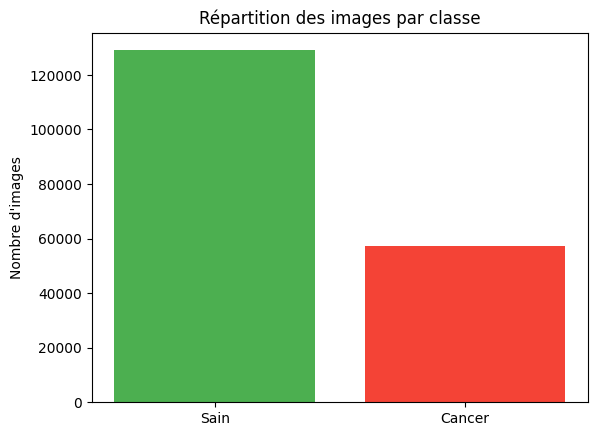

In [10]:
import matplotlib.pyplot as plt

labels = ["Sain", "Cancer"]
counts = [len(healthy_images), len(cancer_images)]

plt.bar(labels, counts, color=["#4CAF50", "#F44336"])
plt.title("Répartition des images par classe")
plt.ylabel("Nombre d'images")
plt.show()

### Data augmentation

In [3]:
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import os

class IDCFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.labels = []
        self.transform = transform

        for root, _, files in os.walk(root_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    full_path = os.path.join(root, file)
                    label = int(os.path.basename(os.path.dirname(full_path)))
                    self.image_paths.append(full_path)
                    self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

### Modèle Resnet

In [8]:
dataset = IDCFolderDataset(root_dir="C:/Users/mahmo/OneDrive/Documents/Ruban rose/ruban_rose/IDC_regular_ps50_idx5", transform=None)

# Split 80/20
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Ajouter les transforms après le split
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [24]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights='IMAGENET1K_V2')

# Adapter la dernière couche
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)
model = model.to(device)

# Freeze sauf fc
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\mahmo/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:36<00:00, 2.84MB/s]


In [5]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.float().to(device)
        optimizer.zero_grad()
        outputs = model(inputs).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += inputs.size(0)
    return total_loss / total, correct / total

In [6]:
def validate(model, loader, criterion):
    model.eval()  # mode évaluation
    total_loss, correct, total = 0., 0, 0

    with torch.no_grad():  # pas de calcul de gradient
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.float().to(device)

            outputs = model(inputs).squeeze(1)  # [B] au lieu de [B, 1]
            loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)

            preds = (torch.sigmoid(outputs) > 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total += inputs.size(0)

    return total_loss / total, correct / total

In [ ]:
EPOCHS = 10
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)
    print(f"Epoch {epoch+1}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

### Subset Dataset

In [9]:
from torch.utils.data import Subset

# Prendre les 5000 premières images seulement
subset_size = 5000
indices = list(range(subset_size))

subset_dataset = Subset(dataset, indices)

In [8]:
train_size = int(0.8 * len(subset_dataset))
val_size = len(subset_dataset) - train_size

train_dataset, val_dataset = random_split(subset_dataset, [train_size, val_size])

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [9]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights='IMAGENET1K_V2')

# Adapter la dernière couche
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)
model = model.to(device)

# Freeze sauf fc
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.float().to(device)
        optimizer.zero_grad()
        outputs = model(inputs).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += inputs.size(0)
    return total_loss / total, correct / total

In [11]:
def validate(model, loader, criterion):
    model.eval()  # mode évaluation
    total_loss, correct, total = 0., 0, 0

    with torch.no_grad():  # pas de calcul de gradient
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.float().to(device)

            outputs = model(inputs).squeeze(1)  # [B] au lieu de [B, 1]
            loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)

            preds = (torch.sigmoid(outputs) > 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total += inputs.size(0)

    return total_loss / total, correct / total

In [12]:
train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []

EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

Epoch 1: train_acc=0.8363, val_acc=0.8690
Epoch 2: train_acc=0.8575, val_acc=0.8690
Epoch 3: train_acc=0.8575, val_acc=0.8690
Epoch 4: train_acc=0.8602, val_acc=0.8780
Epoch 5: train_acc=0.8675, val_acc=0.8890
Epoch 6: train_acc=0.8758, val_acc=0.8990
Epoch 7: train_acc=0.8882, val_acc=0.9050
Epoch 8: train_acc=0.8950, val_acc=0.9130
Epoch 9: train_acc=0.8995, val_acc=0.9120
Epoch 10: train_acc=0.8958, val_acc=0.9110


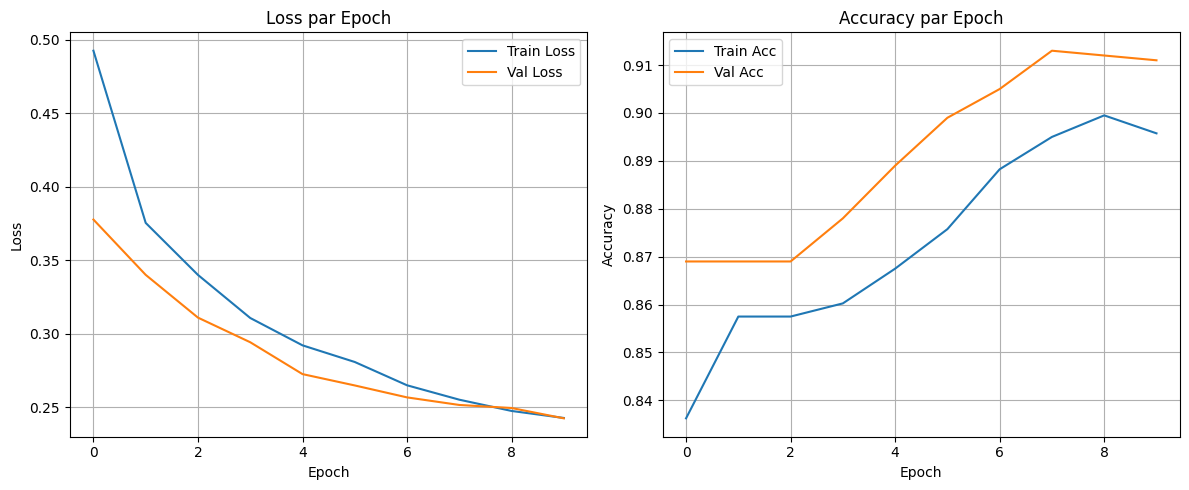

In [13]:
import matplotlib.pyplot as plt

# Courbe de loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss par Epoch')
plt.legend()
plt.grid(True)

# Courbe de précision
plt.subplot(1, 2, 2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy par Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [15]:
torch.save(model.state_dict(), "resnet50_idc.pt")

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import torch

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for inputs, labels in val_loader: 
        inputs = inputs.to(device)
        outputs = model(inputs).squeeze(1)
        preds = (torch.sigmoid(outputs).cpu() > 0.5).long()  # binarise
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.numpy())

# Affiche les métriques
print("📊 Rapport de classification :")
print(classification_report(all_labels, all_preds, digits=4))

print("🧩 Matrice de confusion :")
print(confusion_matrix(all_labels, all_preds))

📊 Rapport de classification :
              precision    recall  f1-score   support

           0     0.9286    0.9724    0.9500       869
           1     0.7333    0.5038    0.5973       131

    accuracy                         0.9110      1000
   macro avg     0.8310    0.7381    0.7736      1000
weighted avg     0.9030    0.9110    0.9038      1000

🧩 Matrice de confusion :
[[845  24]
 [ 65  66]]


### Modèle Resnet50 (images contrast)

In [ ]:
from torch.utils.data import WeightedRandomSampler  
from collections import Counter  
import numpy as np  

In [30]:
dataset = IDCFolderDataset(root_dir="C:/Users/mahmo/OneDrive/Documents/Ruban rose/ruban_rose/IDC_regular_ps50_idx5_ctr", transform=None)

# Prendre les 5000 premières images seulement
subset_size = 5000
indices = list(range(subset_size))

subset_dataset2 = Subset(dataset, indices)

In [ ]:
subset_labels = [labels[i] for i in indices]
class_counts = Counter(subset_labels)
for cls, count in class_counts.items():
    print(f"Classe {cls}: {count} images dans le subset de 5000")

Classe 0: 4299 images dans le subset de 5000
Classe 1: 701 images dans le subset de 5000


In [ ]:
# Sélectionner 2500 indices pour chaque classe

labels = dataset.labels  

indices_0 = [i for i, label in enumerate(labels) if label == 0]
indices_1 = [i for i, label in enumerate(labels) if label == 1]

# Prendre 2500 au hasard pour chaque classe
import random
random.seed(42)
selected_0 = random.sample(indices_0, 2500)
selected_1 = random.sample(indices_1, 2500)

# Fusionner et mélanger
balanced_indices = selected_0 + selected_1
random.shuffle(balanced_indices)

# Créer le subset équilibré
subset_balanced = Subset(dataset, balanced_indices)
print(f"Subset équilibré : {len(subset_balanced)} images (classe 0: {len(selected_0)}, classe 1: {len(selected_1)})")

Subset équilibré : 5000 images (classe 0: 2500, classe 1: 2500)


In [46]:
from torch.utils.data import WeightedRandomSampler
import numpy as np
from collections import Counter

train_size = int(0.8 * len(subset_balanced))
val_size = len(subset_balanced) - train_size

train_dataset, val_dataset = random_split(subset_balanced, [train_size, val_size])

# Appliquer les transforms
train_dataset.dataset.dataset.transform = train_transform  # Note: double .dataset à cause du Subset
val_dataset.dataset.dataset.transform = val_transform

# WeightedRandomSampler pour équilibrer automatiquement
def create_weighted_sampler(dataset):
    # Extraire tous les labels du train_dataset
    labels = []
    for i in range(len(dataset)):
        _, label = dataset[i]
        labels.append(label)
    
    # Compter les occurrences de chaque classe
    label_counts = Counter(labels)
    print(f"📊 Distribution originale du train:")
    for label, count in label_counts.items():
        print(f"   Classe {label}: {count} images ({count/len(labels)*100:.1f}%)")
    
    # Calculer les poids (inverse de la fréquence)
    class_weights = {label: 1.0/count for label, count in label_counts.items()}
    
    # Assigner un poids à chaque échantillon
    sample_weights = [class_weights[label] for label in labels]
    
    # Créer le sampler
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(dataset),
        replacement=True  # Important pour le rééquilibrage
    )
    
    print(f"✅ Rééquilibrage automatique activé:")
    for label, count in label_counts.items():
        print(f"   Classe {label}: poids = {class_weights[label]:.4f}")
    
    return sampler

In [47]:
# Créer le sampler équilibré
train_sampler = create_weighted_sampler(train_dataset)

# DataLoaders avec rééquilibrage automatique
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    sampler=train_sampler  # Utilise le sampler au lieu de shuffle=True
)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"\n🚀 DataLoaders créés:")
print(f"   Train: {len(train_dataset)} échantillons (avec rééquilibrage)")
print(f"   Val: {len(val_dataset)} échantillons")

📊 Distribution originale du train:
   Classe 1: 2003 images (50.1%)
   Classe 0: 1997 images (49.9%)
✅ Rééquilibrage automatique activé:
   Classe 1: poids = 0.0005
   Classe 0: poids = 0.0005

🚀 DataLoaders créés:
   Train: 4000 échantillons (avec rééquilibrage)
   Val: 1000 échantillons


In [48]:
# Vérifier l'équilibrage en pratique sur quelques batches
def verify_balance(loader, num_batches=10):
    """Vérifie la distribution sur quelques batches"""
    all_labels = []
    
    for i, (_, labels) in enumerate(loader):
        if i >= num_batches:
            break
        all_labels.extend(labels.tolist())
    
    distribution = Counter(all_labels)
    print(f"📈 Distribution sur {num_batches} batches ({len(all_labels)} échantillons):")
    for label, count in distribution.items():
        percentage = count/len(all_labels)*100
        print(f"   Classe {label}: {count} échantillons ({percentage:.1f}%)")

print("Vérification de l'équilibrage automatique:")
verify_balance(train_loader)

Vérification de l'équilibrage automatique:
📈 Distribution sur 10 batches (320 échantillons):
   Classe 0: 153 échantillons (47.8%)
   Classe 1: 167 échantillons (52.2%)


In [49]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights='IMAGENET1K_V2')

# Adapter la dernière couche
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)
model = model.to(device)

# Freeze sauf fc
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

In [50]:
train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []

EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

Epoch 1: train_acc=0.6977, val_acc=0.7650
Epoch 2: train_acc=0.7900, val_acc=0.7740
Epoch 3: train_acc=0.7857, val_acc=0.7730
Epoch 4: train_acc=0.7850, val_acc=0.7730
Epoch 5: train_acc=0.7945, val_acc=0.7730
Epoch 6: train_acc=0.8005, val_acc=0.7800
Epoch 7: train_acc=0.8060, val_acc=0.7790
Epoch 8: train_acc=0.7933, val_acc=0.7800
Epoch 9: train_acc=0.8035, val_acc=0.7800
Epoch 10: train_acc=0.8203, val_acc=0.7830


In [51]:
torch.save(model.state_dict(), "resnet50_idc_clahe.pt")

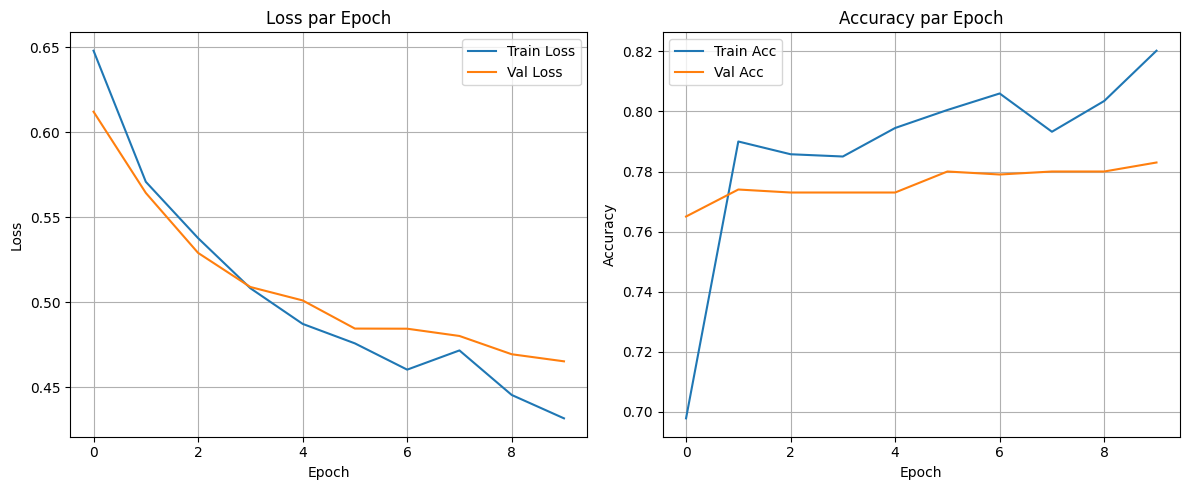

In [52]:
import matplotlib.pyplot as plt

# Courbe de loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss par Epoch')
plt.legend()
plt.grid(True)

# Courbe de précision
plt.subplot(1, 2, 2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy par Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [53]:
from sklearn.metrics import classification_report, confusion_matrix
import torch

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for inputs, labels in val_loader: 
        inputs = inputs.to(device)
        outputs = model(inputs).squeeze(1)
        preds = (torch.sigmoid(outputs).cpu() > 0.5).long()  # binarise
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.numpy())

# Affiche les métriques
print("📊 Rapport de classification :")
print(classification_report(all_labels, all_preds, digits=4))

print("🧩 Matrice de confusion :")
print(confusion_matrix(all_labels, all_preds))

📊 Rapport de classification :
              precision    recall  f1-score   support

           0     0.7918    0.7714    0.7815       503
           1     0.7745    0.7948    0.7845       497

    accuracy                         0.7830      1000
   macro avg     0.7832    0.7831    0.7830      1000
weighted avg     0.7832    0.7830    0.7830      1000

🧩 Matrice de confusion :
[[388 115]
 [102 395]]


### Optuna

In [54]:
def build_model():
    model = models.resnet50(weights='IMAGENET1K_V2')
    
    # Adapter la dernière couche
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 1)
    )
    
    # Freeze sauf fc
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True
    
    return model

In [ ]:
import optuna
import torch
import torch.nn as nn
from sklearn.metrics import recall_score

def objective(trial):
    # Hyperparamètres à optimiser
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    threshold = trial.suggest_float("threshold", 0.4, 0.6)

    # Créer le modèle
    model = build_model()  # à adapter avec ta fonction
    model.to(device)

    # Optimiseur & critère
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    # Entraîner pendant 3 epochs pour aller vite
    for epoch in range(10):
        train_one_epoch(model, train_loader, optimizer, criterion)

    # Évaluer
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs).squeeze(1)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > threshold).astype(int)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)

    # Métrique à maximiser : recall de la classe 1
    recall = recall_score(all_labels, all_preds, pos_label=1)
    return recall


In [56]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

[I 2025-07-28 21:13:18,681] A new study created in memory with name: no-name-b97e1901-4ee9-417b-9a9e-a2a3ce740f21


[I 2025-07-28 22:48:28,348] Trial 0 finished with value: 0.7585513078470825 and parameters: {'lr': 0.00036597327080296394, 'weight_decay': 1.8021477312674583e-05, 'threshold': 0.566198397160909}. Best is trial 0 with value: 0.7585513078470825.
[I 2025-07-29 00:13:05,756] Trial 1 finished with value: 0.7585513078470825 and parameters: {'lr': 0.00040050181785791214, 'weight_decay': 9.375710515755073e-05, 'threshold': 0.5869124795293006}. Best is trial 0 with value: 0.7585513078470825.
[I 2025-07-29 09:20:19,213] Trial 2 finished with value: 0.7505030181086519 and parameters: {'lr': 7.909658869383568e-05, 'weight_decay': 2.6101017488687625e-05, 'threshold': 0.585378174615337}. Best is trial 0 with value: 0.7585513078470825.
[I 2025-07-29 10:45:56,054] Trial 3 finished with value: 0.8591549295774648 and parameters: {'lr': 0.00015097991407701683, 'weight_decay': 1.7741354503665943e-05, 'threshold': 0.41949221333737063}. Best is trial 3 with value: 0.8591549295774648.
[I 2025-07-29 15:49:48,

In [57]:
best_trial = study.best_trial
print("🥇 Meilleur score :", best_trial.value)
print("🔧 Meilleurs hyperparamètres :", best_trial.params)

🥇 Meilleur score : 0.8611670020120724
🔧 Meilleurs hyperparamètres : {'lr': 0.00016627342740481045, 'weight_decay': 1.2752593473105497e-06, 'threshold': 0.4388168405504627}


In [58]:
# Utiliser les meilleurs hyperparamètres trouvés par Optuna pour réentraîner le modèle

best_params = best_trial.params
lr = best_params['lr']
weight_decay = best_params['weight_decay']
threshold = best_params['threshold']

# Reconstruire le modèle
model = build_model()
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.BCEWithLogitsLoss()

train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    print(f"Epoch {epoch+1}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

Epoch 1: train_acc=0.7378, val_acc=0.7700
Epoch 2: train_acc=0.7850, val_acc=0.7790
Epoch 3: train_acc=0.8120, val_acc=0.7780
Epoch 4: train_acc=0.8063, val_acc=0.7840
Epoch 5: train_acc=0.8043, val_acc=0.7780
Epoch 6: train_acc=0.8043, val_acc=0.7790
Epoch 7: train_acc=0.8065, val_acc=0.7830
Epoch 8: train_acc=0.8257, val_acc=0.7910
Epoch 9: train_acc=0.8025, val_acc=0.7870
Epoch 10: train_acc=0.8275, val_acc=0.7950


In [59]:
torch.save(model.state_dict(), "resnet50_idc_best_optuna.pt")

In [60]:
from sklearn.metrics import classification_report, confusion_matrix
import torch

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for inputs, labels in val_loader: 
        inputs = inputs.to(device)
        outputs = model(inputs).squeeze(1)
        preds = (torch.sigmoid(outputs).cpu() > 0.5).long()  # binarise
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.numpy())

# Affiche les métriques
print("📊 Rapport de classification :")
print(classification_report(all_labels, all_preds, digits=4))

print("🧩 Matrice de confusion :")
print(confusion_matrix(all_labels, all_preds))

📊 Rapport de classification :
              precision    recall  f1-score   support

           0     0.8053    0.7813    0.7931       503
           1     0.7852    0.8089    0.7968       497

    accuracy                         0.7950      1000
   macro avg     0.7952    0.7951    0.7950      1000
weighted avg     0.7953    0.7950    0.7950      1000

🧩 Matrice de confusion :
[[393 110]
 [ 95 402]]
